# Variable Construction and Classifications

This notebook explains the construction and classification of the major variables in the merged dataset, focusing on:
1. **LLM-Based Role Classifications** (Academic, Business, Creative, Entrepreneur, Other, Technical).
2. **Pre-Founding Prior Position Variables** (Role, Geography, RICS Industry, and ONET Occupations).
3. **Venture Post-Founding Variables** (Role, Geography, and RICS Industry).
4. **Geographic Classifications and Silicon Valley Indicator**.
5. **Quality spell-level filtering and categorical summaries**.

## 1. LLM-Based Role Classifications

The core variable `category` classifies the founder's primary prior role (extracted from the `role_k500_v3` classification) into one of 6 distinct occupational categories defined in the paper. 

### Classification Methodology
Using OpenAI's `gpt-4o-mini` model, we classified the **501 unique roles** in the `role_k500_v3` taxonomy under the following rules:
- **Academic**: Roles associated with universities, research institutes, teaching, or academic research (e.g., University Professor, Researcher, Art Educator).
- **Business**: Corporate management, marketing, sales, accounting, finance, strategy, consulting, corporate legal, etc. (e.g., Marketing Coordinator, Business Development, Strategy Consultant, Account Executive). *Accountants are explicitly grouped here.*
- **Creative**: Roles associated with design, writing, arts, media production, entertainment (e.g., Visual Designer, Media Producer, Content Writer, UX Designer, Sports Coach).
- **Entrepreneur**: Roles associated with starting companies or founding ventures (e.g., Entrepreneur, Co-Founder, Startup Founder).
- **Technical**: Engineering, computer science, software development, application programming, and hard sciences like biology and chemistry (e.g., Software Engineer, Solutions Architect, Design Engineer, Embedded Systems Engineer, Biologist, Chemist).
- **Other**: Roles that do not fit into the above categories, including medical doctors, service staff, and general administrators. *Doctors are explicitly grouped here.*

Let's load the generated classifications and inspect the distribution of roles across these categories.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load role classification results
class_file = "../C1 - Data Extraction/Extract General Data/Variable classification/classified_roles.csv"
df_class = pd.read_csv(class_file)

# Print total roles classified
print(f"Total unique roles classified: {len(df_class)}")
df_class.head(10)

Total unique roles classified: 476


,role,category,description
0,Marketing Coordinator,Business,As a role focused on facilitating marketing ef...
1,Software Engineer,Technical,This role involves the development and mainten...
2,Business Development,Business,Business Development roles focus on creating s...
3,Entrepreneur,Entrepreneur,This role is defined by the act of starting an...
4,Community Outreach Coordinator,Other,This role focuses on engaging with community m...
5,Researcher,Academic,Researchers are primarily involved in conducti...
6,Sales Director,Business,Sales Directors manage sales teams and strateg...
7,Educator,Academic,Educators are involved in teaching and develop...
8,Account Executive,Business,Account Executives work with clients to manage...
9,Strategy Consultant,Business,Strategy Consultants advise organizations on b...


### Category Distribution
Let's analyze the number of unique roles that fall into each of the 6 categories.

category
Business        163
Other           145
Technical       125
Creative         25
Academic         17
Entrepreneur      1
Name: count, dtype: int64


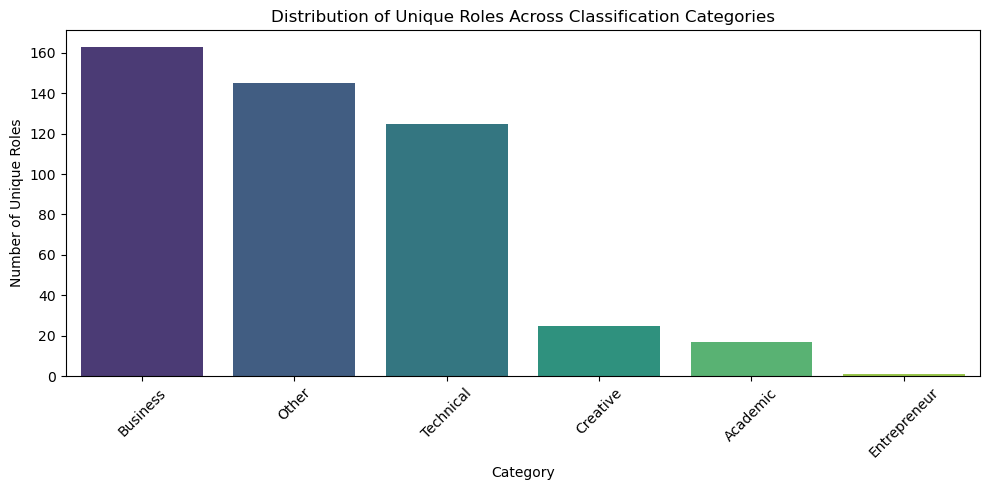

In [2]:
# Show counts per category
category_counts = df_class['category'].value_counts()
print(category_counts)

# Visualize
plt.figure(figsize=(10, 5))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis', hue=category_counts.index, legend=False)
plt.title('Distribution of Unique Roles Across Classification Categories')
plt.xlabel('Category')
plt.ylabel('Number of Unique Roles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Examples of Classified Roles in Each Category

In [3]:
for cat in df_class['category'].unique():
    print(f"=== Category: {cat} ===")
    samples = df_class[df_class['category'] == cat].head(5)
    for idx, row in samples.iterrows():
        print(f" - {row['role']}: {row['description']}")
    print()

=== Category: Business ===
 - Marketing Coordinator: As a role focused on facilitating marketing efforts and campaigns within a corporate structure, it aligns with business operations.
 - Business Development: Business Development roles focus on creating strategic partnerships and opportunities for growth within corporations, fitting squarely within the business category.
 - Sales Director: Sales Directors manage sales teams and strategies within corporate settings, which aligns with business functions.
 - Account Executive: Account Executives work with clients to manage accounts and drive sales, fulfilling a key business role within organizations.
 - Strategy Consultant: Strategy Consultants advise organizations on business strategies and improvements, characteristic of business consultancy roles.

=== Category: Technical ===
 - Software Engineer: This role involves the development and maintenance of software applications, which is a core aspect of technical fields like computer scien

## 2. Pre-Founding (Prior Position) Variables

For the **prior position** held immediately before the founding event, we extract several dimensions of characteristics from the user's last non-founding job:

### A. Location/Geography
- **`prior_metro_area` / `prior_msa`**: The metropolitan area name and official Census MSA name of the prior employer.
- **`prior_country`**: The country code where the prior employer was located.

### B. Hierarchical Role Taxonomy (`prior_role_kXX_v3`)
To capture the founder's experience at different granularities, job roles are clustered at various levels in the Revelio occupational classification taxonomy. The number in the variable name indicates the total number of unique occupational clusters defined at that hierarchical level:
- **Coarse Role (`prior_role_k50_v3`)**: Job titles grouped into 50 broad occupational categories (e.g. Sales, Software Development, Engineering).
- **Medium Roles (`prior_role_k150_v3` to `prior_role_k1500_v3`)**: Increasingly specific categories, grouping job titles into 150, 500, 1000, or 1500 clusters.
- **Highly Specific Roles (`prior_role_k5000_v3` to `prior_role_k15000_v3`)**: Fine-grained clusters grouping job titles into 5,000, 10,000, or 15,000 distinct roles.

### C. Hierarchical Industry Taxonomy (`prior_rics_kXX`)
Employer industries are coded according to the Revelio Industry Classification System (RICS) at three distinct hierarchical granularities:
- **`prior_rics_k50`**: Broad industry sectors (up to 50 categories, e.g. Information Technology Services, Consumer Goods).
- **`prior_rics_k200`**: Medium-level industry classifications (up to 200 categories, e.g. Management Consulting Services, Semiconductor and Electronics Manufacturing).
- **`prior_rics_k400`**: Fine-grained, specific industry subcategories (up to 400 categories).

## 3. Venture (Post-Founding) Variables

For the **founded venture**, similar geographic, role, and industry attributes are captured at the time of the founding event:

### A. Location/Geography
- **`venture_metro_area` / `venture_msa`**: The metropolitan area name and official Census MSA name where the venture was established.
- **`venture_country`**: The country where the venture is based.

### B. Hierarchical Role Taxonomy (`venture_role_kXX_v3`)
Represents the founder's job title inside their own startup (e.g., Founder, CEO, CTO), coded using the same hierarchical clusters from `k50` to `k15000`:
- **`venture_role_k50_v3`** (coarse role, e.g. Executives)
- **`venture_role_k500_v3`** (medium role, e.g. Founder/Chief Executive Officer)
- **`venture_role_k15000_v3`** (highly specific title)

### C. Hierarchical Industry Taxonomy (`venture_rics_kXX`)
Represents the industrial classification of the founded startup at three hierarchical levels:
- **`venture_rics_k50`** (broad venture sectors)
- **`venture_rics_k200`** (medium venture classifications)
- **`venture_rics_k400`** (fine-grained venture subcategories)

In [4]:
# Load a small sample of the merged dataset to demonstrate hierarchical columns
merged_file = "../D - Data/D3 - Refined Datasets for Analysis/Founder_Level_Merged_Dataset.csv"
if os.path.exists(merged_file):
    df_sample = pd.read_csv(merged_file, nrows=5)
    
    print("=== Example of Role Taxonomy Hierarchies (Broad to Specific) ===")
    role_cols = ['prior_title_raw', 'prior_role_k50_v3', 'prior_role_k500_v3', 'prior_role_k15000_v3']
    display(df_sample[role_cols].head(3))
    
    print("\n=== Example of Industry Taxonomy Hierarchies (Broad to Specific) ===")
    ind_cols = ['prior_naics_description', 'prior_rics_k50', 'prior_rics_k200', 'prior_rics_k400']
    display(df_sample[ind_cols].head(3))
else:
    print(f"Merged dataset not found at {merged_file}. Please run the pipeline first.")

=== Example of Role Taxonomy Hierarchies (Broad to Specific) ===


,prior_title_raw,prior_role_k50_v3,prior_role_k500_v3,prior_role_k15000_v3
0,Statistical & Data Analyst Intern,Data Analyst,Data Analyst,Data Analyst Intern
1,Consultant | Strategy & Operations,Business Development Strategist,Strategy Consultant,Business Strategy
2,Resident Assistant,Teacher,Student Services,Resident Advisor



=== Example of Industry Taxonomy Hierarchies (Broad to Specific) ===


,prior_naics_description,prior_rics_k50,prior_rics_k200,prior_rics_k400
0,Surgical and Medical Instrument Manufacturing,Healthcare and Wellness Services,Medical Equipment,Medical Devices and Equipment
1,Offices of Certified Public Accountants,Consulting and Advisory Services,Management Consulting Services,Management Consulting Services
2,"Colleges, Universities, and Professional Schools",Education Services,Higher Education and Research,Research Universities


## 4. Geographic Variable Construction and Silicon Valley Indicator

Geographic locations of founders' previous employers and their subsequently founded ventures are coded using Metropolitan Statistical Areas (MSAs) and metro area strings from LinkedIn and Revelio profiles:
- **Venture Location (`venture_metro_area`, `venture_msa`, `venture_country`)**: Indicates the MSA/metro area where the founded venture is based.
- **Prior Location (`prior_metro_area`, `prior_msa`, `prior_country`)**: Indicates the location of the previous employer prior to founding.

### Silicon Valley (Bay Area) Indicator
Silicon Valley / Bay Area ventures are identified by checking whether the venture's metropolitan area matches San Francisco or San Jose. In terms of data variables:
- `venture_msa` contains: `San Francisco-Oakland-Fremont CA MSA` or `San Jose-Sunnyvale-Santa Clara CA MSA`.
- `venture_metro_area` contains: `san francisco metropolitan area` or `san jose metropolitan area (california)`.

For a full visualization of founder geographies (including a geographic bubble map of US metros) and code implementation of the Silicon Valley indicator, refer to [US_Geographies_and_Silicon_Valley_Classification.ipynb](file:///Users/milanmiric/Documents/Research/Active%20Papers/LinkedIn%20Entreprenurship%20&%20Experience%20%5BPaper%202%5D/Data%20Extraction%20and%20Analysis/C1%20-%20Data%20Extraction/Extract%20General%20Data/Variable%20classification/US_Geographies_and_Silicon_Valley_Classification.ipynb).

## 5. Summary of Major Categorical Variables and Founding Spell Filters

### Categorical Variables Summary
- **`prior_role_category`**: A 6-category occupational classification of the user's last role prior to founding (Academic, Business, Creative, Entrepreneur, Other, Technical).
- **`prior_role_k500_v3`**: A standardized role classification with 501 unique roles.
- **`prior_rics_k200`**: A RICS classification with 200 distinct industrial classes for prior position employers.
- **`venture_rics_k200`**: A RICS classification with 200 distinct industrial classes for the founded ventures.

### Founding Spell Filtering Criteria
To ensure the analysis is based on genuine and viable entrepreneurial events, we apply the following quality filters to founding spells:
1. **Valid Platform ID / LinkedIn URL Existence**: The venture must have a valid `venture_firm_id` (non-null and non-zero). A missing or zero ID indicates the company does not have a platform page (or its LinkedIn URL does not exist).
2. **Minimum Venture Duration**: The venture must last for **at least one year** (`venture_duration_years >= 1`). Spells lasting less than one year are filtered out as they represent ephemeral or inactive entities.

Let's run a quick code block to summarize the distribution of these major categorical variables under the filtered sample.

In [5]:
# Load and apply quality filters to demonstrate categorical distributions
merged_file = "../D - Data/D3 - Refined Datasets for Analysis/Founder_Level_Merged_Dataset.csv"
if os.path.exists(merged_file):
    df_full = pd.read_csv(merged_file)
    
    # Apply the founding spell filters
    df_filtered = df_full[df_full['venture_firm_id'].notnull() & (df_full['venture_firm_id'] != 0)].copy()
    df_filtered = df_filtered[df_filtered['venture_duration_years'] >= 1].copy()
    df_filtered = df_filtered[df_filtered['YEARFOUNDED'].notnull()].copy()
    df_filtered = df_filtered[(df_filtered['YEARFOUNDED'] >= 2000) & (df_filtered['YEARFOUNDED'] <= 2024)].copy()
    
    # Max 10 founders co-founder filter
    founder_counts = df_filtered.groupby('venture_firm_id')['user_id'].transform('nunique')
    df_filtered = df_filtered[founder_counts <= 10].copy()
    
    # Merge classified roles to get prior_role_category
    class_roles_path = "../C1 - Data Extraction/Extract General Data/Variable classification/classified_roles.csv"
    if os.path.exists(class_roles_path):
        df_class = pd.read_csv(class_roles_path, usecols=['role', 'category'])
        df_filtered = df_filtered.merge(df_class, left_on='prior_role_k500_v3', right_on='role', how='left')
        df_filtered = df_filtered.rename(columns={'category': 'prior_role_category'})
    
    print(f"--- Filtered Dataset Summary ---")
    print(f"Total founding spells analyzed: {len(df_filtered):,}\n")
    
    # Summary of prior_role_category
    if 'prior_role_category' in df_filtered.columns:
        print("=== Distribution of prior_role_category ===")
        print(df_filtered['prior_role_category'].value_counts(dropna=False))
        print()
    
    # Summary of top 10 prior_role_k500_v3
    print("=== Top 10 prior_role_k500_v3 Roles ===")
    print(df_filtered['prior_role_k500_v3'].value_counts().head(10))
    print()
    
    # Summary of top 10 venture_rics_k200 Industries
    print("=== Top 10 venture_rics_k200 Industries ===")
    print(df_filtered['venture_rics_k200'].value_counts().head(10))
else:
    print("Merged dataset not found.")

--- Filtered Dataset Summary ---
Total founding spells analyzed: 52,496

=== Distribution of prior_role_category ===
prior_role_category
Business        22209
Technical       13862
Other            5500
Academic         4573
Creative         2766
NaN              2038
Entrepreneur     1548
Name: count, dtype: int64

=== Top 10 prior_role_k500_v3 Roles ===
prior_role_k500_v3
Software Engineer                 4661
Business Development              3888
Marketing Coordinator             2366
Product Manager                   1882
Solutions Architect               1767
Researcher                        1551
Entrepreneur                      1548
Community Outreach Coordinator    1400
Real Estate Officer               1371
Investment Advisor                1216
Name: count, dtype: int64

=== Top 10 venture_rics_k200 Industries ===
venture_rics_k200
Enterprise Software and IT Services    8498
Digital Commerce Services              4894
Miscellaneous                          2187
Media and En